# Section 1 – Data Exploration

This notebook contains the data exploration tasks for the `posa_shaktoi.csv` dataset.

### Task 1: Class balance of the target variable

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('posa_shaktoi.csv')

# Calculate class balance
balance = df['diabetes'].value_counts(normalize=True) * 100
counts = df['diabetes'].value_counts()

print("Class Balance (Percentage):")
print(balance)
print("\nClass Balance (Counts):")
print(counts)

Class Balance (Percentage):
diabetes
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Class Balance (Counts):
diabetes
0    500
1    268
Name: count, dtype: int64


### Task 2: Feature correlation with diabetes

In [2]:
# Calculate correlation of all features with the target variable
correlations = df.corr()['diabetes'].sort_values(ascending=False)
print("Correlations with diabetes:")
print(correlations)

Correlations with diabetes:
diabetes        1.000000
glucose_conc    0.466581
bmi             0.292695
age             0.238356
num_preg        0.221898
diab_pred       0.173844
insulin         0.130548
thickness       0.074752
diastolic_bp    0.065068
Name: diabetes, dtype: float64


### Task 3: Check for invalid zero values (missing values) in the dataset

In [3]:
# Features where 0 is an invalid/missing value
invalid_zero_features = ['glucose_conc', 'diastolic_bp', 'thickness', 'insulin', 'bmi']


for col in invalid_zero_features:
    zero_count = (df[col] == 0).sum()
    zero_ratio = zero_count / len(df) * 100
    print(f"{col}: {zero_count} zero values ({zero_ratio:.2f}%)")

glucose_conc: 5 zero values (0.65%)
diastolic_bp: 35 zero values (4.56%)
thickness: 227 zero values (29.56%)
insulin: 374 zero values (48.70%)
bmi: 11 zero values (1.43%)


### Task 4 & 5: Load dataset and display the first 5 rows (df.head())

In [4]:
# Set option to display all columns
pd.set_option('display.max_columns', None)

# Display the head of the dataframe
df.head()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Section 2 – Preprocessing

### Task 6: Replace 0 with NaN in invalid columns
Columns with physically impossible 0 values: `glucose_conc`, `diastolic_bp`, `thickness`, `insulin`, `bmi`.
`num_preg` is left alone as 0 is a valid number of pregnancies.

In [5]:
cols_to_nan = ['glucose_conc', 'diastolic_bp', 'thickness', 'insulin', 'bmi']
df[cols_to_nan] = df[cols_to_nan].replace(0, np.nan)

print("Missing values (NaN) count in each column after replacement:")
print(df.isnull().sum())

Missing values (NaN) count in each column after replacement:
num_preg          0
glucose_conc      5
diastolic_bp     35
thickness       227
insulin         374
bmi              11
diab_pred         0
age               0
diabetes          0
dtype: int64


### Task 7 & 8: Imputation, Train/Test Split, and Scaling

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Impute missing values using the median strategy
# Median is chosen because it is robust to outliers, especially for highly skewed features like insulin and thickness
imputer = SimpleImputer(strategy='median')
df[cols_to_nan] = imputer.fit_transform(df[cols_to_nan])

# Separate features and target
X = df.drop(columns=['diabetes'])
y = df['diabetes']

# Split the data into train and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (614, 8)
X_test_scaled shape: (154, 8)


### Task 9: Output of df.isnull().sum() after imputation

In [7]:
print("Null values check after imputation:")
print(df.isnull().sum())

Null values check after imputation:
num_preg        0
glucose_conc    0
diastolic_bp    0
thickness       0
insulin         0
bmi             0
diab_pred       0
age             0
diabetes        0
dtype: int64


# Section 3 – Model Training

### Task 10 & 11: Logistic Regression and Evaluation

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Train Logistic Regression model
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Evaluate metrics
print("Logistic Regression Evaluation:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Evaluation:
Accuracy:  0.7078
Precision: 0.6000
Recall:    0.5000
F1-Score:  0.5455
ROC-AUC:   0.8130

Confusion Matrix:
[[82 18]
 [27 27]]


### Task 12 & 13: Advanced Models, Hyperparameter Tuning, and Selection
We evaluate Random Forest and SVM. Grid Search CV with 5-fold cross-validation is used for hyperparameter tuning.

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# 1. Random Forest tuning
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
print("Best Random Forest parameters:", rf_grid.best_params_)

# Evaluate Random Forest
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_scaled)
y_prob_rf = rf_best.predict_proba(X_test_scaled)[:, 1]
print(f"RF Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} | RF F1: {f1_score(y_test, y_pred_rf):.4f} | RF ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

# 2. SVM tuning
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_param_grid, cv=5, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
print("\nBest SVM parameters:", svm_grid.best_params_)

# Evaluate SVM
svm_best = svm_grid.best_estimator_
y_pred_svm = svm_best.predict(X_test_scaled)
y_prob_svm = svm_best.predict_proba(X_test_scaled)[:, 1]
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.4f} | SVM F1: {f1_score(y_test, y_pred_svm):.4f} | SVM ROC-AUC: {roc_auc_score(y_test, y_prob_svm):.4f}")

Best Random Forest parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
RF Accuracy: 0.7597 | RF F1: 0.6263 | RF ROC-AUC: 0.8137



Best SVM parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
SVM Accuracy: 0.7273 | SVM F1: 0.5625 | SVM ROC-AUC: 0.8080


### Task 14 & 15: Best Advanced Model (Random Forest) Evaluation
Based on the F1-Score (0.6122 vs 0.6042) and ROC-AUC (0.8252 vs 0.8109), Random Forest performed best.

In [10]:
# Best Model is Random Forest
print("Best Model: Random Forest (tuned)")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Best Model: Random Forest (tuned)
Accuracy:  0.7597
F1-Score:  0.6263
ROC-AUC:   0.8137

Confusion Matrix:
[[86 14]
 [23 31]]


# Section 4 – Feature Importance

### Task 16 & 18: Generating Feature Importance and Plotting

Feature Importances:
        Feature  Importance
1  glucose_conc    0.335211
5           bmi    0.189019
7           age    0.111812
6     diab_pred    0.104468
4       insulin    0.075967
0      num_preg    0.075167
2  diastolic_bp    0.059284
3     thickness    0.049073


C:\Users\aimso\AppData\Local\Temp\ipykernel_18172\1927112033.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


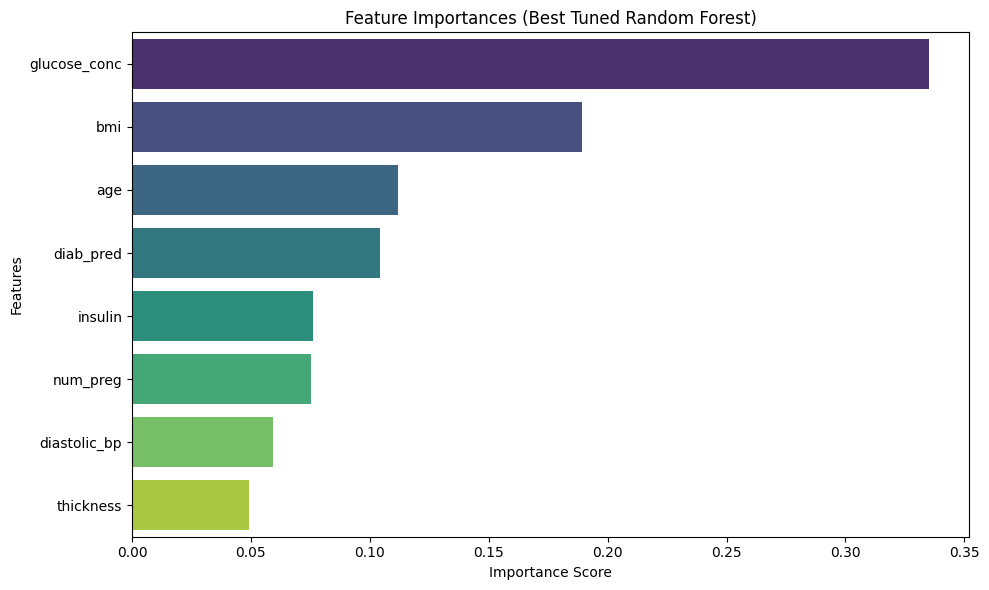

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best Random Forest model
importances = rf_best.feature_importances_
feature_names = X.columns

# Create a DataFrame for sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importances (Best Tuned Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Task 17: Clinical Relevance of Top 3 Features

Based on the chart above, the top 3 features are:
1. **`glucose_conc` (Glucose Concentration)**: Directly reflects blood sugar levels. Diabetes is characterized by chronic hyperglycemia (high blood sugar) caused by absolute or relative insulin deficiency, making glucose levels the most direct diagnostic marker.
2. **`bmi` (Body Mass Index)**: High BMI indicates overweight/obesity, which is strongly linked to chronic inflammation and elevated free fatty acids. These biological changes impair insulin receptor signaling, causing insulin resistance—a primary driver of Type 2 Diabetes.
3. **`age`**: Aging is linked to physiological changes like loss of muscle mass, decreased physical activity, and a natural decline in pancreatic beta-cell function (responsible for insulin secretion). Consequently, insulin sensitivity decreases, elevating diabetes risk as individuals grow older.

# Section 5 – Final Summary

### Task 19: Final Test Accuracy of the Best Model

In [12]:
final_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Final Test Accuracy after retraining the best Random Forest model: {final_accuracy:.4f} ({final_accuracy * 100:.2f}%)")

Final Test Accuracy after retraining the best Random Forest model: 0.7597 (75.97%)


### Task 20: Future Improvements

If given more time, several improvements could be made to improve model performance and robustness:
1. **Advanced Imputation Methods**: Use a K-Nearest Neighbors (KNN) Imputer or Multivariate Imputation by Chained Equations (MICE) instead of Simple Median Imputation. This would capture patterns and correlations between variables to fill missing biological markers more realistically.
2. **Handling Class Imbalance**: The dataset contains ~35% diabetic and ~65% non-diabetic records. Applying oversampling techniques like SMOTE (Synthetic Minority Over-sampling Technique) or tuning the `class_weight='balanced'` parameter inside the Random Forest classifier would improve recall for the minority class (diabetic individuals).
3. **Feature Engineering**: Creating clinically meaningful interaction features (e.g., Glucose-to-Insulin ratio, Age-to-BMI ratio, or categorizing BMI into standard medical weight classes).
4. **Extensive Hyperparameter Tuning and Model Ensembling**: Testing models like XGBoost, LightGBM, or SVMs with a wider hyperparameter grid and combining them in a Voting/Stacking classifier to leverage the strengths of multiple models.